# IPR Outcome Prediction — Submission Notebook

Self-contained notebook: load `features.csv` (sitting next to this file) and reproduce the modeling pipeline end-to-end.

End-to-end: feature frame → trained model. Mirrors the production code at `src/ml_uspto/models/train.py::train_and_evaluate_cv` and `src/ml_uspto/models/tune.py::grid_search_cv`. Every load-bearing piece — preprocessor, encoders, MODELS dict, MODEL_GRIDS, time-aware split, CV, evaluation, grid search — is inlined as a cell. The notebook is fully self-contained: no imports from the production package.

**Glossary (used throughout)**
- **IPR**: Inter Partes Review — a USPTO administrative trial where a petitioner challenges an issued patent's claims as unpatentable.
- **PTAB**: Patent Trial and Appeal Board — the USPTO body that adjudicates IPRs.
- **FWD**: Final Written Decision — PTAB's final ruling that resolves a fully-tried IPR.
- **T₀**: query-time cutoff for a given row (here: petition filing date). Any feature derived from rows with date ≥ T₀ would leak future information.
- **`cancelled`**: binary label = 1 iff the petitioner won (claims found unpatentable in the FWD, or the patentee terminated under conditions equivalent to a loss).
- **`label_resolution_date`**: the date the outcome became observable (FWD-issue date, else termination date) — used by `PriorEncoder` to gate base-rate aggregations.

**Sections**
1. Imports
2. Configuration — constants, `ModelName`, `MODELS`, `MODEL_GRIDS`
3. Preprocessor — `FrequencyEncoder`, `PriorEncoder`, `build_preprocessor`, `build_pipeline`
4. Training primitives — `time_split`, `time_series_cv`, `evaluate_model`
5. Notebook helpers — loaders, `TrainingConfig`, `run_training`, plot fns
6. Load the data
7. Quickstart
8. Step-by-step
9. Overriding the estimator
10. Overriding the preprocessor
11. Comparing estimators
12. Hyperparameter grid search

Leakage discipline: T₀-rolling categorical encodings are precomputed once over the full corpus by `attach_rolling_encodings` (strict-`<` gate on filing/resolution date — leakage-free by construction). The per-fold pipeline (`build_pipeline` + `time_series_cv`) only refits OHE + median imputer.


## 1. Imports

Only sklearn / stdlib. Everything domain-specific is defined inline below.

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*sklearn\.utils\.parallel\.delayed.*",
    category=UserWarning,
)

from dataclasses import dataclass
from enum import StrEnum
from pathlib import Path
from typing import Any

import itertools
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## 2. Configuration

Constants, the `ModelName` enum, and the `MODELS` factory dict. Add a new estimator by appending here.


In [2]:
# Sentinel inserted by the OHE branch in place of NaN — turns missingness into an explicit one-hot level.
MISSING_CATEGORY_SENTINEL: str = "__missing__"

# Group keys for PriorEncoder. Each tuple becomes one prior branch (rate + count features).
PRIOR_GROUP_COLUMNS: tuple[tuple[str, ...], ...] = (
    ("petitioner_real_party",),                          # repeat-petitioner experience
    ("owner_real_party",),                                # repeat-owner experience
    ("petitioner_real_party", "owner_real_party"),       # this exact pair's history
    ("technology_center",),                               # TC base rate
    ("patent_number",),                                   # multi-petition campaigns
    ("ptab_era",),                                        # period base rate (Director-memo regime)
)
PRIOR_DATE_COLUMN: str = "petition_filing_date"
PRIOR_RESOLUTION_DATE_COLUMN: str = "label_resolution_date"

OHE_CATEGORICAL_COLUMNS: tuple[str, ...] = (
    "technology_center", "cpc_section", "ptab_era", "entity_size", "inventor_geo",
)
FREQUENCY_CATEGORICAL_COLUMNS: tuple[str, ...] = ("petitioner_real_party", "owner_real_party")


class ModelName(StrEnum):
    RANDOM_FOREST = "random_forest"
    LOGISTIC = "logistic"


# LR is wrapped in its own (StandardScaler, LogisticRegression) Pipeline so
# `build_pipeline` can wrap it identically to RF. Scaling is mandatory: the
# post-preprocessor matrix mixes prior counts, frequency encodings, and binary
# OHE columns — unscaled L2 follows the largest. Trees ignore scale, so RF
# skips it. Grid keys for LR use the `lr__` prefix (sklearn nested-pipeline).
MODELS: dict[ModelName, Any] = {
    ModelName.RANDOM_FOREST: lambda: RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        max_features=0.3,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    ModelName.LOGISTIC: lambda: Pipeline(
        steps=[
            ("scale", StandardScaler()),
            (
                "lr",
                LogisticRegression(
                    solver="saga",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=42,
                ),
            ),
        ]
    ),
}


# Keys are sklearn `set_params` paths; LR uses `lr__` because its estimator is a Pipeline.
MODEL_GRIDS: dict[ModelName, dict[str, list[Any]]] = {
    ModelName.RANDOM_FOREST: {
        "n_estimators": [800, 1500],
        "max_depth": [10, 20, None],
        "max_features": [0.3, "sqrt"],
        "min_samples_leaf": [2, 5],
    },
    ModelName.LOGISTIC: {
        "lr__C": [0.01, 0.1, 1.0, 10.0],
        "lr__penalty": ["l1", "l2"],
    },
}


## 3. Preprocessor

Two stages:

1. **`attach_rolling_encodings(features, y)`** — fits `PriorEncoder` (one per group in `PRIOR_GROUP_COLUMNS`) and `FrequencyEncoder` once over the full corpus and appends their outputs as numeric columns. Both encoders are row-local and T₀-gated by strict-`<` on filing / label-resolution date, so corpus-level fitting is leakage-free and gives every row the richest possible pre-T₀ history.
2. **`build_preprocessor()`** — a `ColumnTransformer` with two refit-per-fold branches: OHE for closed taxonomies (TC, CPC section) and a median imputer over the remaining numerics (raw features + the precomputed rolling encodings). The `Pipeline` wrapper is what enforces refit-per-fold semantics for these two branches.


In [3]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Per-column rolling frequency encoding, gated by T₀.

    For a row at T₀ and column `c=v`, returns the count of training
    rows where `c=v` and whose `date_column` is strictly before T₀.
    Unseen values, NaN values, and values whose every train occurrence
    is ≥ T₀ all map to 0. Mirrors `PriorEncoder`'s T₀ discipline so a
    row dated 2017 cannot see a 2020 filing the same party will
    eventually make.
    """

    def __init__(self, date_column="petition_filing_date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        X = self._as_frame(X)
        dates = pd.to_datetime(X[self.date_column], errors="coerce").to_numpy()
        valid = ~pd.isna(dates)
        dates = dates[valid]
        order = np.argsort(dates, kind="stable")
        dates_sorted = dates[order]

        feature_cols = [c for c in X.columns if c != self.date_column]
        self.feature_names_in_ = np.asarray(feature_cols, dtype=object)

        self.group_dates_: dict[str, dict[object, np.ndarray]] = {}
        for col in feature_cols:
            # Same valid-mask + date-sort permutation as `dates`, so
            # walking vals_sorted = walking train rows chronologically;
            # each per-value list comes out date-sorted for free, which
            # is what `searchsorted` needs at transform.
            vals_sorted = X[col].to_numpy()[valid][order]
            idx_by_val: dict[object, list[int]] = {}
            for i, v in enumerate(vals_sorted):
                idx_by_val.setdefault(v, []).append(i)
            self.group_dates_[col] = {
                v: dates_sorted[np.asarray(idxs)] for v, idxs in idx_by_val.items()
            }
        return self

    def transform(self, X):
        X = self._as_frame(X)
        q_dates = pd.to_datetime(X[self.date_column], errors="coerce").to_numpy()
        # NaT queries would sort as max under searchsorted and silently
        # return the full training count — leak everything. Zero them out.
        nat_mask = pd.isna(q_dates)
        out = np.zeros((len(X), len(self.feature_names_in_)), dtype=np.int64)

        for j, col in enumerate(self.feature_names_in_):
            per_val = self.group_dates_.get(col, {})
            col_vals = X[col].to_numpy()
            rows_by_val: dict[object, list[int]] = {}
            for i, v in enumerate(col_vals):
                rows_by_val.setdefault(v, []).append(i)
            for v, row_idxs in rows_by_val.items():
                train_dates = per_val.get(v)
                if train_dates is None:
                    continue
                row_idxs_arr = np.asarray(row_idxs)
                idx = np.searchsorted(train_dates, q_dates[row_idxs_arr], side="left")
                out[row_idxs_arr, j] = idx
        if nat_mask.any():
            out[nat_mask, :] = 0
        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            names = [c for c in input_features if c != self.date_column]
        else:
            names = list(self.feature_names_in_)
        return np.asarray([f"{n}_frequency" for n in names], dtype=object)

    @staticmethod
    def _as_frame(X):
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(np.asarray(X))


In [4]:
class PriorEncoder(BaseEstimator, TransformerMixin):
    """Per-row leakage-safe rolling cancellation rate over a group key.

    Returns (rate, count) per row. Rate is the mean of `cancelled` over
    training rows sharing the group whose **label-resolution date**
    (FWD-issue, else termination) strictly precedes T₀ — gating on
    petition_filing_date would leak labels from trials whose FWD issued
    after T₀. Cold-start rows (group with no qualifying history) fall
    back to the global rolling rate at T₀. See
    `docs/scope/prediction_scope.md` §4 and
    `docs/engineering/preprocessing.md` §1.2.
    """

    def __init__(
        self,
        group_columns,
        date_column="petition_filing_date",
        resolution_date_column="label_resolution_date",
    ):
        # sklearn's clone() requires constructor args verbatim — don't normalize here.
        self.group_columns = group_columns
        self.date_column = date_column
        self.resolution_date_column = resolution_date_column

    def fit(self, X, y=None):
        if y is None:
            raise ValueError("PriorEncoder requires y at fit time")
        X = self._as_frame(X)
        y_arr = np.asarray(y, dtype=np.float64)
        res_dates = pd.to_datetime(X[self.resolution_date_column], errors="coerce").to_numpy()
        keys = self._build_keys(X)

        # Rows with unknown resolution date can't be gated against any T₀
        # without leaking — drop them from the index entirely.
        valid = ~pd.isna(res_dates)
        res_dates, keys, y_arr = res_dates[valid], keys[valid], y_arr[valid]

        order = np.argsort(res_dates, kind="stable")
        dates_sorted, keys_sorted, y_sorted = res_dates[order], keys[order], y_arr[order]

        # Bucket by key (Python loop — composite tuple keys break numpy broadcasting).
        idx_by_key: dict[object, list[int]] = {}
        for i, k in enumerate(keys_sorted):
            idx_by_key.setdefault(k, []).append(i)

        self.group_dates_ = {k: dates_sorted[np.asarray(ix)] for k, ix in idx_by_key.items()}
        self.group_cum_y_ = {k: np.cumsum(y_sorted[np.asarray(ix)]) for k, ix in idx_by_key.items()}
        self.global_dates_ = dates_sorted
        self.global_cum_y_ = np.cumsum(y_sorted)
        self.global_rate_ = float(y_arr.mean()) if len(y_arr) else 0.0
        self.feature_label_ = "_".join(list(self.group_columns))
        return self

    def transform(self, X):
        X = self._as_frame(X)
        # Query at T₀ (petition date); train rows are indexed by their
        # resolution date in fit, so a training row only contributes once
        # its label crystallized strictly before this row's T₀.
        dates = pd.to_datetime(X[self.date_column], errors="coerce").to_numpy()
        keys = self._build_keys(X)
        # NaT queries sort as max under searchsorted → would silently
        # pull in the full training history. Mask and override at the end.
        nat_mask = pd.isna(dates)
        out_rate = np.full(len(X), np.nan, dtype=np.float64)
        out_count = np.zeros(len(X), dtype=np.int64)

        rows_by_key: dict[object, list[int]] = {}
        for i, k in enumerate(keys):
            rows_by_key.setdefault(k, []).append(i)

        for group_key, row_idxs in rows_by_key.items():
            train_dates = self.group_dates_.get(group_key)
            if train_dates is None:
                continue
            cum_y = self.group_cum_y_[group_key]
            row_arr = np.asarray(row_idxs)
            idx = np.searchsorted(train_dates, dates[row_arr], side="left")
            sum_y = np.where(idx > 0, cum_y[np.clip(idx - 1, 0, len(cum_y) - 1)], 0.0)
            out_rate[row_arr] = np.where(idx > 0, sum_y / np.maximum(idx, 1), np.nan)
            out_count[row_arr] = idx

        # Cold-start fallback: global rolling rate at T₀, not 0 — see preprocessing.md §1.2.
        nan_mask = np.isnan(out_rate)
        if nan_mask.any():
            fb_idx = np.searchsorted(self.global_dates_, dates[nan_mask], side="left")
            sum_y_fb = np.where(
                fb_idx > 0,
                self.global_cum_y_[np.clip(fb_idx - 1, 0, len(self.global_cum_y_) - 1)],
                0.0,
            )
            out_rate[nan_mask] = np.where(fb_idx > 0, sum_y_fb / np.maximum(fb_idx, 1), self.global_rate_)

        if nat_mask.any():
            out_rate[nat_mask] = self.global_rate_
            out_count[nat_mask] = 0

        return np.column_stack([out_rate, out_count.astype(np.float64)])

    def get_feature_names_out(self, input_features=None):
        del input_features  # names derived from group_columns, not the input slice
        return np.asarray(
            [f"{self.feature_label_}_prior_rate", f"{self.feature_label_}_prior_count"],
            dtype=object,
        )

    def _build_keys(self, X):
        # Composite keys: NaN components are sentinel-filled before tupling.
        # Reason: tuple equality compares with `==`, and `nan == nan` is False
        # — different NaN objects can fail to bucket together.
        cols = list(self.group_columns)
        if len(cols) == 1:
            return X[cols[0]].astype(object).to_numpy()
        return X[cols].astype(object).fillna("__NA__").agg(tuple, axis=1).to_numpy()

    @staticmethod
    def _as_frame(X):
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(np.asarray(X))


In [5]:
def attach_rolling_encodings(features: pd.DataFrame, y) -> pd.DataFrame:
    """T₀-rolling encodings computed once over the full corpus.

    Both `FrequencyEncoder` and `PriorEncoder` are row-local: each row's
    output uses only corpus rows whose date is strictly before that
    row's T₀. That gating is leakage-free regardless of which subset is
    fitted, so refitting per CV fold throws away pre-T₀ history without
    correctness benefit. We compute these once here and attach them as
    plain numerics; downstream `build_preprocessor` only handles OHE +
    median imputation.

    Holdout→train leakage is structurally impossible: training rows have
    T₀ < holdout cutoff ≤ every holdout row's `label_resolution_date`,
    so the strict-< gate inside the encoders never lets a holdout label
    feed a training row's encoding.
    """
    out = features.copy()
    y_arr = np.asarray(y)
    for group in PRIOR_GROUP_COLUMNS:
        enc = PriorEncoder(
            group_columns=list(group),
            date_column=PRIOR_DATE_COLUMN,
            resolution_date_column=PRIOR_RESOLUTION_DATE_COLUMN,
        ).fit(features, y=y_arr)
        arr = enc.transform(features)
        rate_name, count_name = enc.get_feature_names_out()
        out[rate_name] = arr[:, 0]
        out[count_name] = arr[:, 1]
    freq_cols = [*FREQUENCY_CATEGORICAL_COLUMNS, PRIOR_DATE_COLUMN]
    enc = FrequencyEncoder(date_column=PRIOR_DATE_COLUMN).fit(features[freq_cols])
    arr = enc.transform(features[freq_cols])
    for j, name in enumerate(enc.get_feature_names_out(freq_cols)):
        out[name] = arr[:, j]
    return out


def build_preprocessor() -> ColumnTransformer:
    """Per-fold preprocessor: OHE + median imputer.

    Categorical rolling encodings (`PriorEncoder`, `FrequencyEncoder`) are
    computed once over the full corpus by `attach_rolling_encodings`
    upstream — leakage-free by row-local T₀ gating, so per-fold refit
    only throws away data. This stage handles only per-fold-fittable
    transforms: OHE for closed taxonomies (TC, CPC section) and median
    imputation over the remaining numerics (raw features + the
    precomputed rolling encodings).
    """
    ohe_branch = Pipeline([
        # Fill NaN with sentinel BEFORE encoding — makes missingness an explicit OHE level.
        ("fill_missing", SimpleImputer(strategy="constant", fill_value=MISSING_CATEGORY_SENTINEL)),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int)),
    ])
    return ColumnTransformer(
        transformers=[
            ("ohe", ohe_branch, list(OHE_CATEGORICAL_COLUMNS)),
            ("num_impute", SimpleImputer(strategy="median"), make_column_selector(dtype_include=np.number)),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_pipeline(estimator: BaseEstimator) -> Pipeline:
    """Compose the preprocessor with `estimator` into a refit-per-fold pipeline."""
    return Pipeline([("preprocess", build_preprocessor()), ("model", estimator)])

## 4. Training primitives — split, CV, evaluation

In [6]:
def time_split(X, y, petition_dates, *, holdout_after):
    """Split (X, y, dates) into train (< cutoff) and held-out test (≥ cutoff).

    The held-out tail is the deployment-honest evaluation slice — never
    inspected during selection or hyperparameter search.
    """
    cutoff = pd.Timestamp(holdout_after)
    dates = pd.to_datetime(petition_dates)
    train_mask = dates < cutoff
    test_mask = ~train_mask
    return (
        X.loc[train_mask], X.loc[test_mask],
        y.loc[train_mask], y.loc[test_mask],
        dates.loc[train_mask], dates.loc[test_mask],
    )


DEFAULT_TIME_SERIES_SCORING = ("roc_auc", "average_precision", "f1")


def _date_safe_folds(sorted_dates, n_splits):
    """Forward-walking train/test indices that snap to date transitions.

    Same chunk layout as sklearn's TimeSeriesSplit but pushes each cut
    forward to the first row whose date is strictly greater than the
    previous row's. Same-day rows therefore never straddle a fold
    boundary — joinder cases and multi-petition campaigns are filed in
    same-day batches.
    """
    n = len(sorted_dates)
    chunk = n // (n_splits + 1)

    def snap(idx):
        if idx <= 0:
            return 0
        if idx >= n:
            return n
        return int(np.searchsorted(sorted_dates, sorted_dates[idx - 1], side="right"))

    folds = []
    for k in range(1, n_splits + 1):
        train_end = snap(k * chunk)
        test_end = snap((k + 1) * chunk) if k < n_splits else n
        if train_end >= test_end:
            continue
        folds.append((np.arange(0, train_end), np.arange(train_end, test_end)))
    return folds


def time_series_cv(pipeline, X, y, petition_dates, n_splits=5, scoring=DEFAULT_TIME_SERIES_SCORING):
    """Forward-walking time-series CV against petition_filing_date."""
    order = np.argsort(pd.to_datetime(petition_dates).to_numpy(), kind="stable")
    X_sorted = X.iloc[order].reset_index(drop=True)
    y_sorted = y.iloc[order].reset_index(drop=True)
    sorted_dates = pd.to_datetime(petition_dates).to_numpy()[order]
    return cross_validate(
        pipeline, X_sorted, y_sorted,
        cv=_date_safe_folds(sorted_dates, n_splits),
        scoring=list(scoring),
        n_jobs=-1,
    )

In [7]:
@dataclass
class ModelMetrics:
    model_name: str
    accuracy: float
    roc_auc: float
    classification_report: dict


def evaluate_model(model, X_test, y_test, model_name):
    """Compute held-out metrics. CV picks the model; this number is what you report."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return ModelMetrics(
        model_name=model_name,
        accuracy=accuracy_score(y_test, y_pred),
        roc_auc=roc_auc_score(y_test, y_prob),
        classification_report=classification_report(y_test, y_pred, output_dict=True),
    )

## 5. Notebook helpers — loaders, orchestrator, plot fns

In [8]:
CSV_PATH = Path("features.csv")  # sits next to this notebook

def _parse_dates(df):
    for c in ("petition_filing_date", "decision_issue_date", "termination_date"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def load_features(csv_path: str | Path = CSV_PATH):
    """Load the pre-engineered feature frame (one row per IPR trial)."""
    df = pd.read_csv(csv_path)
    return _parse_dates(df)


def merge_features_with_labels(features, *, mature_days=600, today=None):
    """The submission CSV is already merged; this fn just applies the maturity filter.

    `label_resolution_date` = decision_issue_date if present else termination_date.
    Drops trials whose petition is more recent than `today - mature_days` —
    their `cancelled` label hasn't crystallized yet (~20 mo for FWDs at the
    600-day default, matching `settings.yaml::model.mature_days`).
    """
    merged = features.copy()
    merged["trial_number"] = merged["trial_number"].astype(str)
    merged["patent_number"] = merged["patent_number"].astype(str)
    merged["label_resolution_date"] = merged["decision_issue_date"].combine_first(
        merged["termination_date"]
    )
    merged = merged.drop(columns=["decision_issue_date", "termination_date"])
    if mature_days > 0:
        now = pd.Timestamp(today) if today else pd.Timestamp(pd.Timestamp.today().date())
        cutoff = now - pd.Timedelta(days=mature_days)
        merged = merged[merged["petition_filing_date"] <= cutoff].copy()
    return merged


In [9]:
@dataclass
class TrainingConfig:
    # Defaults match `settings.yaml::model` so notebook runs reproduce
    # the driver runs deterministically. Override per-cell when exploring.
    holdout_after: str | pd.Timestamp = "2023-01-01"
    model_name: ModelName = ModelName.RANDOM_FOREST
    mature_days: int = 600
    cv_folds: int = 5
    today: str | pd.Timestamp | None = "2026-05-05"


@dataclass
class TrainingResult:
    pipeline: Pipeline
    cv_results: dict[str, Any]
    metrics: ModelMetrics
    X_train: pd.DataFrame
    X_test: pd.DataFrame
    y_train: pd.Series
    y_test: pd.Series
    dates_train: pd.Series
    dates_test: pd.Series


def run_training(config, *, features=None, estimator_factory=None):
    """Mirror of drivers/run_train.py. Pass `estimator_factory` to swap the estimator without mutating MODELS."""
    if features is None:
        features = load_features()
    merged = merge_features_with_labels(
        features, mature_days=config.mature_days, today=config.today
    )
    y = merged["cancelled"].astype(int)
    # T₀-rolling encodings computed once over the full corpus before the
    # train/holdout split — strict-< T₀ gating in the encoders makes this
    # leakage-free and gives every row the richest possible pre-T₀ history.
    merged = attach_rolling_encodings(merged, y)
    dates = merged["petition_filing_date"]
    # petition_filing_date + patent_number + label_resolution_date stay in X
    # only as a side effect — they were consumed by attach_rolling_encodings
    # above. The OHE / num_impute branches' selectors ignore them, so
    # remainder="drop" strips them from the post-preprocessor matrix.
    X = merged.drop(columns=["trial_number", "cancelled"])
    # Held-out tail is the deployment-honest slice — never seen by CV or selection.
    X_train, X_test, y_train, y_test, dates_train, dates_test = time_split(
        X, y, dates, holdout_after=config.holdout_after
    )

    # Preprocessor refits inside time_series_cv per fold — no leakage from test rows.
    factory = estimator_factory or MODELS[config.model_name]
    pipeline = build_pipeline(factory())
    cv = time_series_cv(pipeline, X_train, y_train, dates_train, n_splits=config.cv_folds)
    pipeline.fit(X_train, y_train)
    metrics = evaluate_model(pipeline, X_test, y_test, config.model_name.value)

    return TrainingResult(
        pipeline=pipeline, cv_results=cv, metrics=metrics,
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        dates_train=dates_train, dates_test=dates_test,
    )

In [10]:
# Plot helpers — return matplotlib figures for inline display.

def plot_roc(models, X_test, y_test):
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve

    fig, ax = plt.subplots(figsize=(8, 6))
    for name, model in models.items():
        prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set(xlabel="FPR", ylabel="TPR", title="ROC")
    ax.legend()
    fig.tight_layout()
    return fig


def plot_confusion(model, X_test, y_test, *, name="model"):
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_test, model.predict(X_test))
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set(
        xticks=[0, 1], yticks=[0, 1],
        xticklabels=["not cancelled", "cancelled"],
        yticklabels=["not cancelled", "cancelled"],
        xlabel="predicted", ylabel="actual", title=f"Confusion — {name}",
    )
    fig.tight_layout()
    return fig


def plot_feature_importance(pipeline, *, top_n=20, name="model"):
    import matplotlib.pyplot as plt

    pre = pipeline.named_steps["preprocess"]
    model = pipeline.named_steps["model"]
    feat_names = list(pre.get_feature_names_out())
    if hasattr(model, "feature_importances_"):
        importances = np.asarray(model.feature_importances_)
    elif hasattr(model, "coef_"):
        importances = np.abs(np.asarray(model.coef_).ravel())
    else:
        raise AttributeError(f"{type(model).__name__} has no feature_importances_ or coef_")
    idx = np.argsort(importances)[-top_n:]
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.25)))
    ax.barh(range(len(idx)), importances[idx])
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feat_names[i] for i in idx])
    ax.set(xlabel="importance", title=f"Top {top_n} features — {name}")
    fig.tight_layout()
    return fig

## 6. Load the data

`features.csv` is one row per IPR trial: engineered features + the columns the rest of the notebook needs (`cancelled`, `petition_filing_date`, `patent_number`, `decision_issue_date`, `termination_date`).

In [11]:
features = load_features()
print(f"features: {features.shape}")
features.head()


features: (14822, 41)


,trial_number,filing_year,filing_month,art_unit_group,prosecution_span_days_missing,prosecution_span_days,days_grant_to_petition_missing,days_grant_to_petition,days_since_last_assignment,no_recorded_assignment,...,n_grounds_102,n_grounds_103,has_sotera_stipulation,mentions_fintiv_factors,petition_text_length,cancelled,petition_filing_date,patent_number,decision_issue_date,termination_date
0,IPR2026-00196,2026,1,264.0,0,1698.0,0,1672,923.0,0,...,20,4,1,0,137733,0,2026-01-05,11031677,NaT,2026-04-09
1,IPR2026-00092,2025,12,379.0,0,923.0,0,723,1518.0,0,...,5,4,0,0,120560,0,2025-12-18,11850424,NaT,2026-04-14
2,IPR2026-00090,2025,12,379.0,0,2462.0,0,1787,2844.0,0,...,5,4,0,0,118266,0,2025-12-18,10898709,NaT,2026-04-14
3,IPR2026-00091,2025,12,379.0,0,1663.0,0,772,1518.0,0,...,5,4,0,0,121330,0,2025-12-18,11806526,NaT,2026-04-14
4,IPR2026-00152,2025,12,369.0,0,197.0,0,988,NaN,1,...,10,8,0,0,125764,0,2025-12-17,11620701,NaT,2026-03-19


## 7. Quickstart — one-liner end-to-end

`TrainingConfig` carries every knob; `run_training` does merge → maturity-filter → time-split → CV → refit → held-out evaluation.

In [12]:
config = TrainingConfig(
    holdout_after="2023-01-01",
    model_name=ModelName.RANDOM_FOREST,
    mature_days=600,
    cv_folds=5,
)
result = run_training(config, features=features)

cv_auc = result.cv_results["test_roc_auc"]
print(f"train rows: {len(result.X_train)}, held-out: {len(result.X_test)}")
print(f"CV ROC-AUC:    {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")
print(f"held-out AUC:  {result.metrics.roc_auc:.4f}")
print(f"held-out acc:  {result.metrics.accuracy:.4f}")

train rows: 11689, held-out: 1907
CV ROC-AUC:    0.5511 +/- 0.0355
held-out AUC:  0.6106
held-out acc:  0.7756


## 8. Step-by-step — same flow, peeled into editable cells

In [13]:
# 8a. Merge + maturity filter
merged = merge_features_with_labels(features, mature_days=600, today="2026-05-05")
print(f"after maturity filter: {len(merged)} rows")

after maturity filter: 13596 rows


In [13]:
# 8b. Time split — held-out tail vs trainable history.
y = merged["cancelled"].astype(int)
# Compute T₀-rolling encodings once over the full corpus before the split —
# strict-< T₀ gating in the encoders makes this leakage-free and matches
# `run_training` above. Skipping this step drops PriorEncoder columns and
# materially weakens the held-out AUC.
merged = attach_rolling_encodings(merged, y)
dates = merged["petition_filing_date"]
# Date columns stay in X but the OHE/num_impute selectors ignore them; remainder="drop" removes.
X = merged.drop(columns=["trial_number", "cancelled"])

# Date-based split. Random K-fold would let later cancellations train models that score earlier rows.
X_train, X_test, y_train, y_test, dates_train, dates_test = time_split(
    X, y, dates, holdout_after="2023-01-01"
)
print(f"train: {len(X_train)}, test: {len(X_test)}")


train: 11689, test: 1907


In [15]:
# 8c. Forward-walking CV — each test fold sits strictly after its train rows by date.
pipeline = build_pipeline(MODELS[ModelName.RANDOM_FOREST]())
cv = time_series_cv(pipeline, X_train, y_train, dates_train, n_splits=5)
print(f"CV ROC-AUC: {cv['test_roc_auc'].mean():.4f} +/- {cv['test_roc_auc'].std():.4f}")

CV ROC-AUC: 0.5511 +/- 0.0355


In [16]:
# 8d. Refit on full train, evaluate once on held-out.
# CV is for model selection; this number is what you report.
pipeline.fit(X_train, y_train)
metrics = evaluate_model(pipeline, X_test, y_test, "random_forest")
metrics

ModelMetrics(model_name='random_forest', accuracy=0.7755637126376508, roc_auc=0.6105810961986207, classification_report={'0': {'precision': 0.7749737118822292, 'recall': 1.0, 'f1-score': 0.8732227488151659, 'support': 1474.0}, '1': {'precision': 1.0, 'recall': 0.011547344110854504, 'f1-score': 0.0228310502283105, 'support': 433.0}, 'accuracy': 0.7755637126376508, 'macro avg': {'precision': 0.8874868559411146, 'recall': 0.5057736720554272, 'f1-score': 0.44802689952173824, 'support': 1907.0}, 'weighted avg': {'precision': 0.8260677773017335, 'recall': 0.7755637126376508, 'f1-score': 0.680134334820353, 'support': 1907.0}})

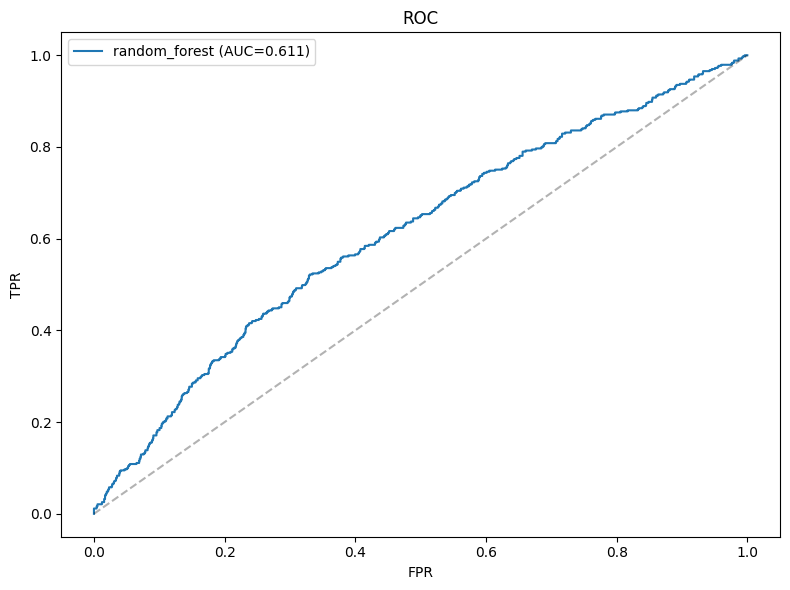

In [17]:
plot_roc({"random_forest": pipeline}, X_test, y_test);

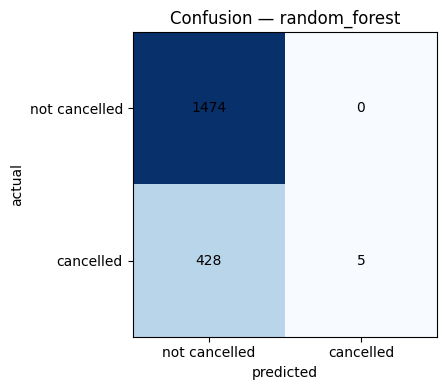

In [18]:
plot_confusion(pipeline, X_test, y_test, name="random_forest");

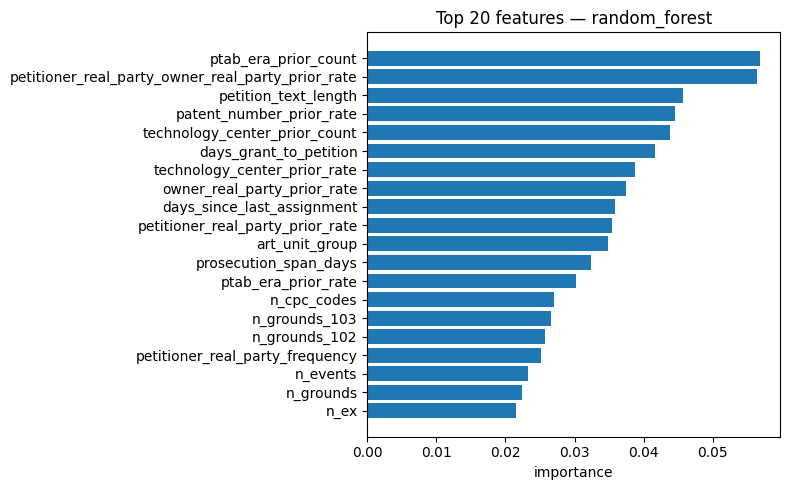

In [19]:
plot_feature_importance(pipeline, top_n=20, name="random_forest");

## 9. Overriding the estimator

Two non-mutating patterns: pass an `estimator_factory` callable to `run_training`, or build a local `MODELS` dict that adds entries on top of the §2 one. The inline `MODELS` stays untouched.

In [20]:
# 9a. Inline factory: tuned RF
def tuned_rf():
    return RandomForestClassifier(
        n_estimators=500, max_depth=15, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1,
    )

tuned = run_training(
    TrainingConfig(holdout_after="2023-01-01", model_name=ModelName.RANDOM_FOREST),
    features=features,
    estimator_factory=tuned_rf,
)
print(f"tuned RF held-out AUC: {tuned.metrics.roc_auc:.4f}")

tuned RF held-out AUC: 0.6108


In [21]:
# 9b. LogisticRegression — pulled from MODELS so the StandardScaler step
# is wired in. Calling LogisticRegression(...) directly without a scaler
# would let the largest-magnitude post-preprocessor column dominate L2.
lr_pipe = build_pipeline(MODELS[ModelName.LOGISTIC]())
lr_cv = time_series_cv(lr_pipe, X_train, y_train, dates_train, n_splits=5)
print(f"LR CV ROC-AUC: {lr_cv['test_roc_auc'].mean():.4f} +/- {lr_cv['test_roc_auc'].std():.4f}")

LR CV ROC-AUC: 0.5391 +/- 0.0315


## 10. Overriding the preprocessor

`build_preprocessor` is the default. To customize, build your own `ColumnTransformer` and wrap it in a `Pipeline` — `time_series_cv` refits the whole composite per fold either way.

In [21]:
# Ablation: drop the precomputed *_prior_rate / *_prior_count columns and
# refit. The rolling encodings live on the frame (added by
# attach_rolling_encodings upstream), so dropping them happens at the
# X-level, not by changing the preprocessor.
prior_cols = [c for c in X_train.columns if c.endswith("_prior_rate") or c.endswith("_prior_count")]
X_train_np = X_train.drop(columns=prior_cols)
no_prior_pipe = build_pipeline(MODELS[ModelName.RANDOM_FOREST]())
no_prior_cv = time_series_cv(no_prior_pipe, X_train_np, y_train, dates_train, n_splits=5)
print(f"no-prior RF CV ROC-AUC: {no_prior_cv['test_roc_auc'].mean():.4f} (vs default w/ priors)")


no-prior RF CV ROC-AUC: 0.5458 (vs default w/ priors)


## 11. Comparing estimators

Side-by-side CV on the same train slice. Pick the highest stable mean, then run §8d once on the held-out tail.

In [23]:
rows = []
for name in (ModelName.RANDOM_FOREST, ModelName.LOGISTIC):
    pipe = build_pipeline(MODELS[name]())
    cv_i = time_series_cv(pipe, X_train, y_train, dates_train, n_splits=5)
    rows.append({
        "model": name.value,
        "cv_roc_auc_mean": cv_i["test_roc_auc"].mean(),
        "cv_roc_auc_std": cv_i["test_roc_auc"].std(),
    })
pd.DataFrame(rows).sort_values("cv_roc_auc_mean", ascending=False)

,model,cv_roc_auc_mean,cv_roc_auc_std
0,random_forest,0.551104,0.035543
1,logistic,0.539055,0.031497


## 12. Hyperparameter grid search

Mirrors `drivers/run_grid_search.py`. Cannot use sklearn's `GridSearchCV` because that would shuffle folds and break date-safe chronology; instead we iterate combos and run the same `time_series_cv` per combo.

The held-out tail (`X_test`) is *not* used here — selection runs on the train slice only, then the chosen combo gets locked into `MODELS[...]` and §8d evaluates it once on the tail.

In [24]:
# 12a. Inline grid_search_cv — iterates combos, runs time_series_cv per combo,
# returns the per-fold AUCs plus the argmax row. Tiny grid for notebook speed;
# the production grid in MODEL_GRIDS above is wider.

def grid_search_cv(X_tr, y_tr, dates_tr, model_name, grid, cv_folds=3):
    keys = list(grid.keys())
    combos = [dict(zip(keys, vals, strict=True)) for vals in itertools.product(*grid.values())]
    entries = []
    for params in combos:
        est = MODELS[model_name]()
        est.set_params(**params)
        pipe = build_pipeline(est)
        cv = time_series_cv(pipe, X_tr, y_tr, dates_tr, n_splits=cv_folds)
        fold_auc = cv.get("test_roc_auc", np.array([]))
        entries.append({
            "params": params,
            "mean_roc_auc": float(fold_auc.mean()),
            "std_roc_auc": float(fold_auc.std()),
            "fold_roc_auc": fold_auc.tolist(),
        })
    best = max(entries, key=lambda e: e["mean_roc_auc"])
    return {"entries": entries, "best": best}


tiny_grid = {"n_estimators": [200, 500], "max_depth": [10, None]}
result_grid = grid_search_cv(X_train, y_train, dates_train, ModelName.RANDOM_FOREST, tiny_grid, cv_folds=3)
print("best:", result_grid["best"]["params"], "→", f"{result_grid['best']['mean_roc_auc']:.4f}")
pd.DataFrame(result_grid["entries"]).sort_values("mean_roc_auc", ascending=False)

best: {'n_estimators': 200, 'max_depth': None} → 0.5185


,params,mean_roc_auc,std_roc_auc,fold_roc_auc
1,"{'n_estimators': 200, 'max_depth': None}",0.518534,0.037137,"[0.5415668731814494, 0.4661420833082718, 0.547..."
3,"{'n_estimators': 500, 'max_depth': None}",0.517123,0.042453,"[0.5492595723984651, 0.4571358314728786, 0.544..."
0,"{'n_estimators': 200, 'max_depth': 10}",0.516839,0.033768,"[0.547217988559213, 0.46973974862927825, 0.533..."
2,"{'n_estimators': 500, 'max_depth': 10}",0.513725,0.038169,"[0.5408740919617585, 0.45974695457424186, 0.54..."


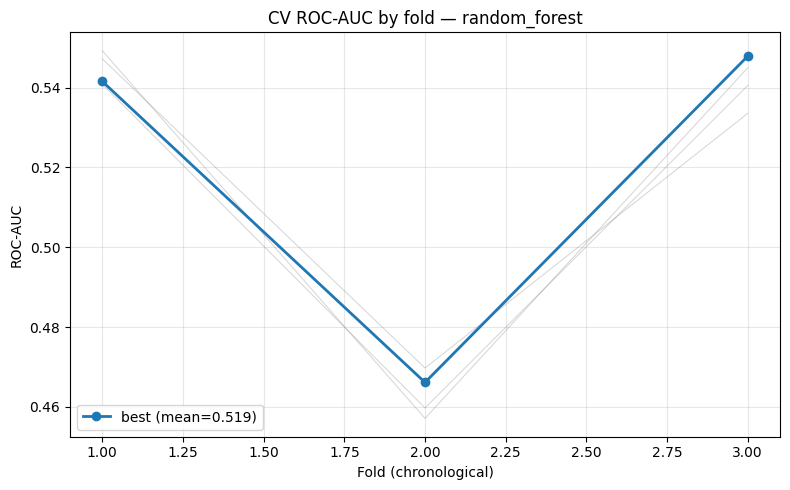

In [25]:
# 12b. Per-fold AUC plot — winner bold, all combos faint grey. Surfaces
# whether the winner is consistent across time or just lucky on one fold.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for entry in result_grid["entries"]:
    ax.plot(range(1, len(entry["fold_roc_auc"]) + 1), entry["fold_roc_auc"],
            color="grey", alpha=0.3, linewidth=0.8)
best_entry = result_grid["best"]
ax.plot(range(1, len(best_entry["fold_roc_auc"]) + 1), best_entry["fold_roc_auc"],
        color="C0", marker="o", linewidth=2.0,
        label=f"best (mean={best_entry['mean_roc_auc']:.3f})")
ax.set(xlabel="Fold (chronological)", ylabel="ROC-AUC", title="CV ROC-AUC by fold — random_forest")
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()